# YHP Credit Assessment — Part 2: Predicting `is_loss`

## Scenario: Binary Classification

This notebook documents the full data science process for predicting whether a
funded SMB loan will record a material credit loss, up to model evaluation.

It follows the structure:
exploratory analysis, pre-processing with explicit leakage controls, four tuned
classifiers, and a single comparison at the end. Where this dataset forced a
departure from that template, the reason is stated at the point of departure.

## Data Dictionary and Project Notes

### Source
- **Table**: `mart_ml_training_set` in `credit_dbt/credit.duckdb`
- **Target**: `is_loss` — true where the loan recorded a material credit loss
- **Grain**: one row per funded loan, 10,000 rows

### Columns
| Column | Role |
|---|---|
| `loan_id` | Identifier. Never a feature. |
| `split` | `train` / `test`, assigned by date. See below. |
| `is_loss` | Target. |
| `received_date` | Kept for error analysis by vintage. **Never a feature** — it defines the split, so a model given it can learn the boundary itself. |
| `feat_001_grouped` | `feat_001` with rare categories collapsed to `OTHER`. |
| `feat_003`, `feat_004`, `feat_015`, `feat_041` | Anonymised categorical features. |
| `is_unobserved_*` | 19 indicators marking where a sentinel code was replaced by NULL. |
| everything else | 94 anonymised numeric features. |

### What the dbt layer already did

Four transformations happen upstream in `mart_ml_training_set`. All four are
**fixed rules** — they need no knowledge of the data, so they cannot move
information from the test set into training.

1. **`loss_amount` is dropped.** It is near-deterministic with the target
   (`is_loss ≈ loss_amount > 0` on 9,847 of 10,000 rows). Leaving it in means a
   careless `SELECT *` trains on the answer. The guard lives in the schema, not
   in a line of notebook code that anyone could delete.
2. **The split is by date, not random** — cutoff `2024-10-01`.
3. **Rare `feat_001` categories collapse to `OTHER`**, using training counts only.
4. **Sentinel codes become NULL**, each with an `is_unobserved` indicator.

Everything that must be **fitted** — encoding, imputation, scaling — is done in
this notebook, on the training rows alone.

### The features are anonymised

Nothing in the source says what any feature represents. Values such as `IND_043`
carry no meaning. No statement in this notebook should be read as causal.

## Why the split is by date and not random `train_test_split`



Profiling found that **5,427 of the 10,000 rows (54.3%) are byte-identical to
another row** across all 99 feature columns, forming 2,435 duplicate groups.
Within every group the rows share the same date, the same label and the same
loss amount — only `loan_id` differs.

A random split would place identical records on both sides. The model would
memorise its training set and score brilliantly on copies of it. Nothing in the
metrics would reveal this.

Because duplicates always share a date, **none of the 2,435 groups straddle the
2024-10-01 cutoff**, so a time split is immune to the leak. It also matches how
the model would really be used: fit on the past, predict the future.

The cost is that the two sides have different base rates — 20.60% train against
23.59% test — because the loss rate drifts upward over the period. That is a
genuine property of the book, not a sampling fault, and it makes the test set
harder than the training set rather than easier.

**Import Libraries**

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
)

from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42

pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid")

Matplotlib is building the font cache; this may take a moment.


**Load the model-ready table**

In [2]:
DB_PATH = "../credit_dbt/credit.duckdb"

with duckdb.connect(DB_PATH, read_only=True) as con:
    df = con.execute("select * from mart_ml_training_set").df()

# feat_004 and feat_015 arrive as bool. Cast them to int so they are picked up
# as numeric features rather than falling between the numeric and categorical
# selectors and reaching the model unscaled. They are binary with no missing
# values, so a one-hot encoding of them would only duplicate the column.
bool_features = [c for c in df.select_dtypes(include=["bool"]).columns if c != "is_loss"]
df[bool_features] = df[bool_features].astype(int)
print(f"Cast to int: {bool_features}")

print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Cast to int: ['feat_004', 'feat_015']
Loaded 10,000 rows and 122 columns


,loan_id,split,is_loss,received_date,feat_001_grouped,feat_003,feat_004,feat_015,feat_041,feat_066_min,...,feat_081_max,feat_082_min,feat_084,feat_085_max,feat_005_trend,feat_022_min,feat_086_sum,feat_087_mean,feat_088_mean,feat_055_sum
0,LRQ-100060,train,False,2023-12-13,IND_183,ST_07,1,0,A,NaN,...,169.0000,"9,997.0000",53.8960,2.0000,"-19,005.0000","9,997.0000",84.0000,"99,997.0000",9.9996,62.0000
1,LRQ-100062,train,False,2019-04-14,IND_019,ST_26,0,1,B,NaN,...,998.0000,330.0000,64.2860,12.0000,"3,948.0000","2,281.0000",464.0000,"54,541.0000",9.9998,"1,088.0000"
2,LRQ-100067,train,True,2019-03-07,IND_048,ST_46,0,1,B,NaN,...,243.0000,38.0000,57.7920,5.0000,610.0000,-33.0000,125.0000,339.0000,9.9998,125.0000
3,LRQ-100278,train,False,2023-02-20,OTHER,ST_41,0,1,A,NaN,...,998.0000,"9,997.0000",59.0910,2.0000,"-1,206.0000","9,997.0000",290.0000,"99,996.5000",5.4999,290.0000
4,LRQ-100504,train,True,2021-01-12,IND_054,ST_06,1,1,B,24.0000,...,7.0000,"9,997.0000",38.3120,1.0000,407.0000,"9,997.0000",83.0000,"99,996.0000",9.9998,49.0000


## Exploratory Data Analysis

EDA is used here to understand the structure of the table, the balance of the
target, how much is missing after the sentinel conversion, and whether the
categorical features separate the target at all.

In [3]:
def data_info(dataframe):
    """Print the shape, dtype mix and missingness summary of a DataFrame."""
    print("Shape:", dataframe.shape)
    print()
    print("Dtypes:")
    print(dataframe.dtypes.value_counts().to_string())
    print()
    missing = dataframe.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    print(f"Columns with missing values: {len(missing)} of {dataframe.shape[1]}")
    print(f"Cells missing overall: {dataframe.isna().sum().sum():,} "
          f"({dataframe.isna().mean().mean() * 100:.1f}%)")
    return missing


missing_summary = data_info(df)
missing_summary.head(15)

Shape: (10000, 122)

Dtypes:
float64           94
int32             19
object             5
int64              2
bool               1
datetime64[us]     1

Columns with missing values: 53 of 122
Cells missing overall: 86,954 (7.1%)


feat_066_min     8695
feat_064_max     7675
feat_030_max     7285
feat_050_min     7247
feat_062_min     6698
feat_070_min     4632
feat_008         4563
feat_017_sum     4316
feat_006         4158
feat_034_mean    3685
feat_010         2837
feat_029_min     2489
feat_052_min     2384
feat_068_min     2228
feat_031_min     2009
dtype: int64

Missingness is much higher than a naive null check on the raw source would
suggest. That is the sentinel conversion working: 19 columns encoded "no
observation" as a large placeholder number such as 1,000,000,000, and those
readings are now honestly recorded as absent. The paired `is_unobserved_*`
indicators preserve the fact that the value was missing, because "no history
available" may itself separate risk.

In [4]:
def separate_columns(dataframe):
    """Split the table into target, identifiers, categorical and numeric features."""
    identifiers = ["loan_id", "split", "received_date"]
    target = "is_loss"

    features = dataframe.drop(columns=identifiers + [target])
    categorical = features.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric = features.select_dtypes(include=[np.number]).columns.tolist()

    # Without this, a column of an unexpected dtype is silently claimed by
    # neither list and reaches the model unscaled and unimputed. That is exactly
    # what happened first time round with the two boolean features: nothing
    # errored, the feature count simply did not add up.
    assert len(categorical) + len(numeric) == features.shape[1], (
        f"{features.shape[1] - len(categorical) - len(numeric)} feature column(s) "
        f"matched neither selector: "
        f"{set(features.columns) - set(categorical) - set(numeric)}"
    )

    return target, identifiers, categorical, numeric


target, identifiers, cat_cols, num_cols = separate_columns(df)

print(f"Target      : {target}")
print(f"Identifiers : {identifiers}")
print(f"Categorical : {len(cat_cols)} -> {cat_cols}")
print(f"Numeric     : {len(num_cols)}")

Target      : is_loss
Identifiers : ['loan_id', 'split', 'received_date']
Categorical : 3 -> ['feat_001_grouped', 'feat_003', 'feat_041']
Numeric     : 115


**Target balance and split sizes**

,loans,losses,base_rate
split,,,
train,8037,1656,0.2060
test,1963,463,0.2359


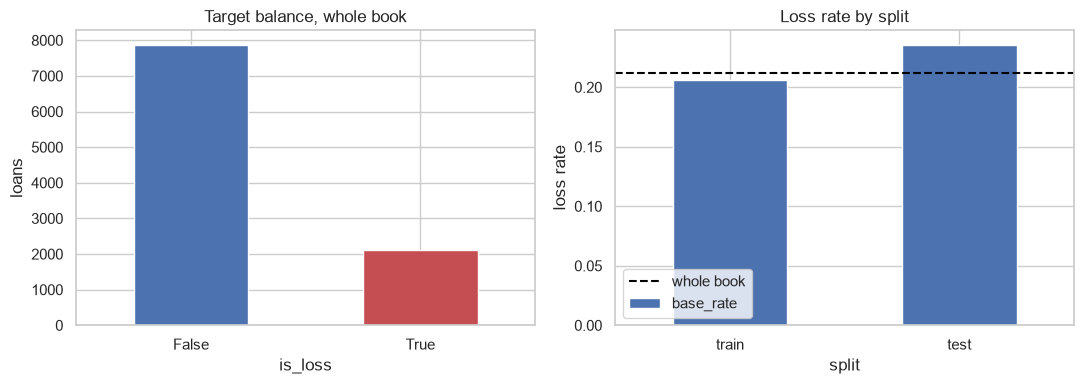

In [5]:
summary = (
    df.groupby("split")
      .agg(loans=("loan_id", "size"),
           losses=("is_loss", "sum"),
           base_rate=("is_loss", "mean"))
      .loc[["train", "test"]]
)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["is_loss"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"])
axes[0].set_title("Target balance, whole book")
axes[0].set_xlabel("is_loss")
axes[0].set_ylabel("loans")
axes[0].tick_params(axis="x", rotation=0)

summary["base_rate"].plot(kind="bar", ax=axes[1], color="#4C72B0")
axes[1].axhline(df["is_loss"].mean(), color="black", linestyle="--", label="whole book")
axes[1].set_title("Loss rate by split")
axes[1].set_ylabel("loss rate")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

The target is imbalanced but not severely so, at roughly one loss in five. This
matters for the choice made later: the brain stroke notebook used SMOTE because
its target was rare, whereas at 21% class weighting is usually enough and
carries less risk on a dataset that is already half duplicates.

**Numerical features against the target**

,count,mean,std,min,25%,50%,75%,max
feat_004,"10,000.0000",0.6362,0.4811,0.0000,0.0000,1.0000,1.0000,1.0000
feat_015,"10,000.0000",0.4140,0.4926,0.0000,0.0000,0.0000,1.0000,1.0000
feat_066_min,"1,305.0000",44.6621,38.8690,0.0000,0.0000,45.0000,77.0000,118.0000
feat_064_max,"2,325.0000","-10,945.9118","6,897.0836","-70,605.0000","-13,551.0000","-9,335.0000","-6,447.0000","1,229.0000"
feat_030_max,"2,715.0000","2,291.4203","18,588.2069",0.0000,192.0000,474.0000,"1,113.5000","650,308.0000"
feat_050_min,"2,753.0000","37,451.9916","86,730.7519",0.0000,"2,167.0000","16,054.0000","41,521.0000","1,837,726.0000"


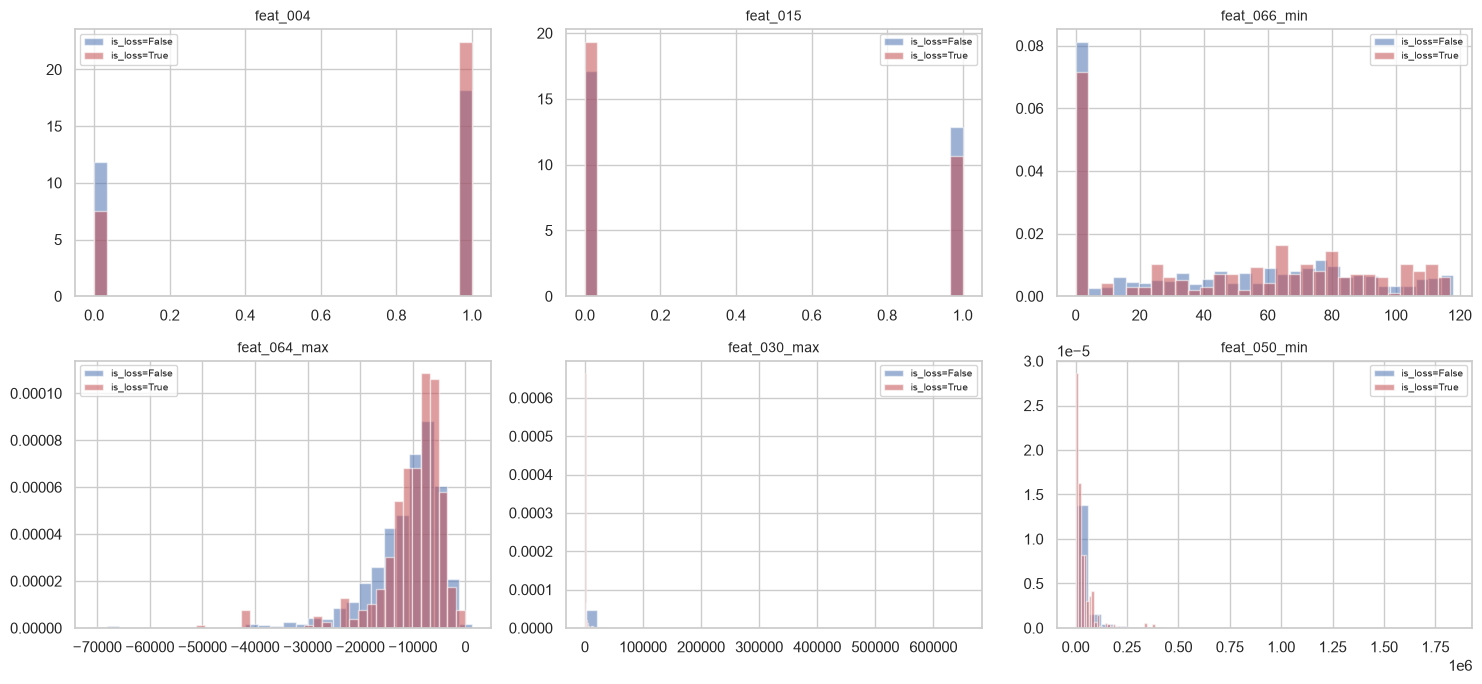

In [6]:
def numerical_eda(dataframe, columns, target_column="is_loss", max_plots=6):
    """Summarise numeric columns and plot their distribution split by the target."""
    chosen = columns[:max_plots]
    display(dataframe[chosen].describe().T)

    fig, axes = plt.subplots(2, 3, figsize=(15, 7))
    for ax, col in zip(axes.ravel(), chosen):
        for value, colour in [(False, "#4C72B0"), (True, "#C44E52")]:
            subset = dataframe.loc[dataframe[target_column] == value, col].dropna()
            if len(subset):
                ax.hist(subset, bins=30, alpha=0.55, density=True,
                        color=colour, label=f"is_loss={value}")
        ax.set_title(col, fontsize=10)
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()


numerical_eda(df, [c for c in num_cols if not c.startswith("is_unobserved_")])

**Categorical features against the target**

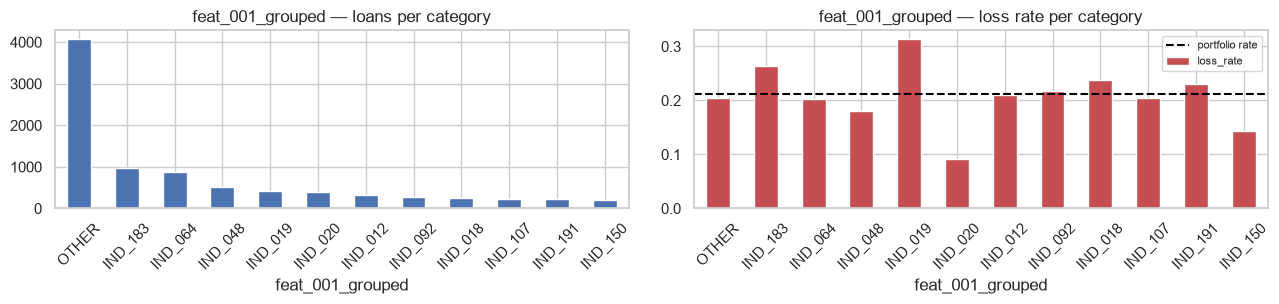

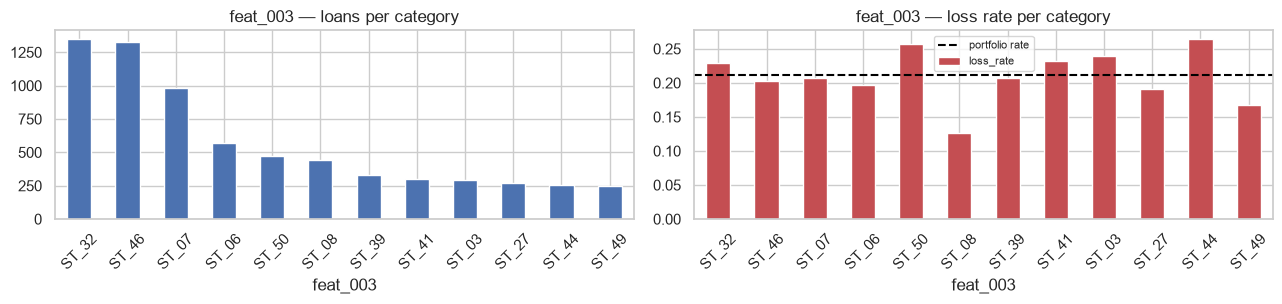

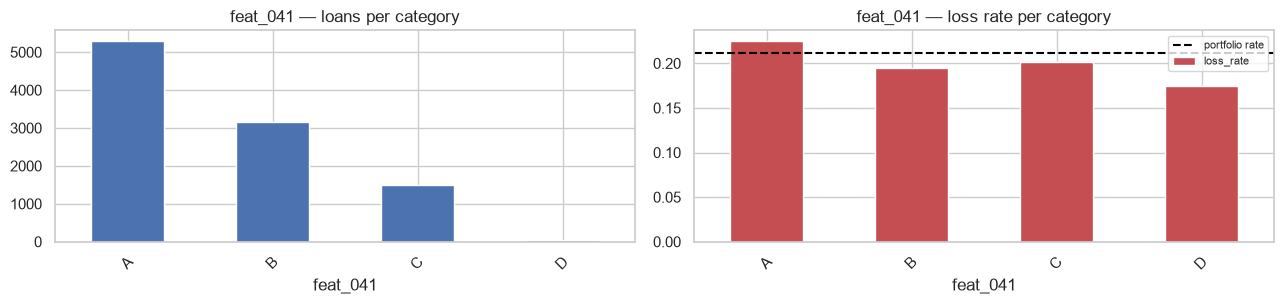

In [7]:
def categorical_eda(dataframe, columns, target_column="is_loss", top_n=12):
    """Show category counts and the loss rate within each category."""
    for col in columns:
        stats = (
            dataframe.groupby(col)
                     .agg(loans=("loan_id", "size"), loss_rate=(target_column, "mean"))
                     .sort_values("loans", ascending=False)
                     .head(top_n)
        )

        fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
        stats["loans"].plot(kind="bar", ax=axes[0], color="#4C72B0")
        axes[0].set_title(f"{col} — loans per category")
        axes[0].tick_params(axis="x", rotation=45)

        stats["loss_rate"].plot(kind="bar", ax=axes[1], color="#C44E52")
        axes[1].axhline(dataframe[target_column].mean(), color="black",
                        linestyle="--", label="portfolio rate")
        axes[1].set_title(f"{col} — loss rate per category")
        axes[1].tick_params(axis="x", rotation=45)
        axes[1].legend(fontsize=8)

        plt.tight_layout()
        plt.show()


categorical_eda(df, cat_cols)

Every categorical feature separates the target to some degree, and the spread
across `feat_001_grouped` and `feat_003` is wide. This is descriptive only. No
control has been applied for vintage or for any other feature, so a category
with a high loss rate is a category worth investigating, not a cause of loss.

## Pre-processing

The aim is to convert the table into a form the models can use **without
letting any information from the test set influence the training set**.

### Order of operations, and why

1. **Split first**, using the `split` column. Nothing is fitted before this point.
2. **One-hot encode** the categorical features. The encoder is fitted on
   training rows only, with `handle_unknown="ignore"` so that the four
   `feat_001` categories which appear in the test period but never in training
   become all-zero rows rather than an error.
3. **Impute** missing numeric values with the **training median**. Imputing
   before the split would let test-set values shift the fill value.
4. **Standardise** numeric features using the **training** mean and standard
   deviation. KNN, SVM and Logistic Regression are all sensitive to scale.

Steps 2, 3 and 4 are all fitted on `X_train` and merely applied to `X_test`.

**Step 1 — split by the pre-assigned column**

In [8]:
train_mask = df["split"] == "train"

X_train_raw = df.loc[train_mask].drop(columns=identifiers + [target])
X_test_raw = df.loc[~train_mask].drop(columns=identifiers + [target])
y_train = df.loc[train_mask, target].astype(int)
y_test = df.loc[~train_mask, target].astype(int)

print(f"train: {X_train_raw.shape[0]:,} rows, base rate {y_train.mean():.4f}")
print(f"test : {X_test_raw.shape[0]:,} rows, base rate {y_test.mean():.4f}")

last_train = df.loc[train_mask, "received_date"].max()
first_test = df.loc[~train_mask, "received_date"].min()
print(f"\nlast training date {last_train}, first test date {first_test}")
assert last_train < first_test, "split is not chronological"
print("chronological split confirmed — no training loan post-dates a test loan")

train: 8,037 rows, base rate 0.2060
test : 1,963 rows, base rate 0.2359

last training date 2024-09-30 00:00:00, first test date 2024-10-02 00:00:00
chronological split confirmed — no training loan post-dates a test loan


**Step 2 — one-hot encode, fitted on training rows only**

In [9]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(X_train_raw[cat_cols])

encoded_names = encoder.get_feature_names_out(cat_cols)


def encode(frame):
    """Apply the fitted encoder and return the frame with categoricals replaced."""
    encoded = pd.DataFrame(
        encoder.transform(frame[cat_cols]),
        columns=encoded_names,
        index=frame.index,
    )
    return pd.concat([frame.drop(columns=cat_cols), encoded], axis=1)


X_train = encode(X_train_raw)
X_test = encode(X_test_raw)

print(f"{len(cat_cols)} categorical columns became {len(encoded_names)} indicator columns")
print(f"feature matrix: {X_train.shape[1]} columns")

3 categorical columns became 79 indicator columns
feature matrix: 194 columns


**Step 3 — impute missing numeric values with the training median**

In [10]:
imputer = SimpleImputer(strategy="median")
imputer.fit(X_train[num_cols])

X_train[num_cols] = imputer.transform(X_train[num_cols])
X_test[num_cols] = imputer.transform(X_test[num_cols])

print("missing values remaining — train:", int(X_train.isna().sum().sum()),
      "test:", int(X_test.isna().sum().sum()))

missing values remaining — train: 0 test: 0


**Step 4 — standardise numeric features using training statistics**

In [11]:
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

display(X_train[num_cols[:5]].describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
feat_004,0.0000,1.0001,-1.3302,0.7518
feat_015,0.0000,1.0001,-0.8938,1.1189
feat_066_min,0.0000,1.0001,-2.7740,5.1324
is_unobserved_feat_066_min,0.0000,1.0001,-2.4348,0.4107
feat_064_max,-0.0000,1.0001,-19.3503,3.4057


### Handling class imbalance

**The main models use `class_weight="balanced"` rather than SMOTE.** The
expectation behind that choice was that on a dataset where 54.3% of rows are
duplicates, SMOTE would interpolate new minority examples between points that
are already copies of each other, adding no information.

That expectation is tested at the end of this notebook rather than assumed —
and, as it turns out, it is not supported. Read the comparison before repeating
the reasoning.

KNN has no `class_weight` parameter, so it is trained on the natural
distribution and its results are read with that in mind.

## Model training and evaluation

Four classifiers are compared, the same four as the brain stroke notebook: KNN,
SVM, Decision Tree and Logistic Regression. Each is tuned over one parameter,
then refitted at its best setting.

### Which metric decides "best"

The brain stroke notebook selected on recall, treating a missed case as the
costly error. Credit scoring works differently: the model's job is to **rank**
loans by risk, and the business then chooses a cut-off according to how much
good business it is willing to decline.

Selection is therefore on **ROC-AUC**, which measures ranking quality
independently of any threshold. **PR-AUC** is reported alongside it because it
is more informative on an imbalanced target. Precision, recall and F1 at the
default 0.5 threshold are reported too, and a threshold table is produced at the
end so the trade-off is visible rather than assumed.

In [12]:
def score_model(model, X_tr, y_tr, X_te, y_te, label, params):
    """Fit a model and return a dict of test-set metrics."""
    model.fit(X_tr, y_tr)

    predictions = model.predict(X_te)

    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_te)[:, 1]
    else:
        scores = model.decision_function(X_te)

    return {
        "model": label,
        "params": params,
        "roc_auc": roc_auc_score(y_te, scores),
        "pr_auc": average_precision_score(y_te, scores),
        "accuracy": accuracy_score(y_te, predictions),
        "precision": precision_score(y_te, predictions, zero_division=0),
        "recall": recall_score(y_te, predictions, zero_division=0),
        "f1_score": f1_score(y_te, predictions, zero_division=0),
    }


def plot_sweep(results, x_column, title, log_x=False):
    """Plot ROC-AUC, PR-AUC, recall and precision across a parameter sweep."""
    plt.figure(figsize=(8, 4.5))
    for metric in ["roc_auc", "pr_auc", "recall", "precision"]:
        plt.plot(results[x_column], results[metric], marker="o", label=metric)
    if log_x:
        plt.xscale("log")
    plt.xlabel(x_column)
    plt.ylabel("score")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

### K-Nearest Neighbours

KNN classifies by distance, so the standardisation step matters most here.
Different values of `k` trade sensitivity to noise against oversmoothing.

,k,roc_auc,pr_auc,precision,recall,f1_score
0,5,0.5273,0.2498,0.2353,0.1123,0.1520
1,10,0.5119,0.2457,0.2353,0.0432,0.0730
2,15,0.5273,0.2483,0.2090,0.0302,0.0528
3,20,0.5362,0.2560,0.1786,0.0108,0.0204
4,25,0.5347,0.2529,0.2727,0.0194,0.0363
5,30,0.5327,0.2533,0.0909,0.0022,0.0042
6,35,0.5352,0.2573,0.0833,0.0022,0.0042
7,40,0.5397,0.2651,0.0000,0.0000,0.0000
8,45,0.5377,0.2638,0.2000,0.0022,0.0043
9,50,0.5382,0.2635,0.0000,0.0000,0.0000


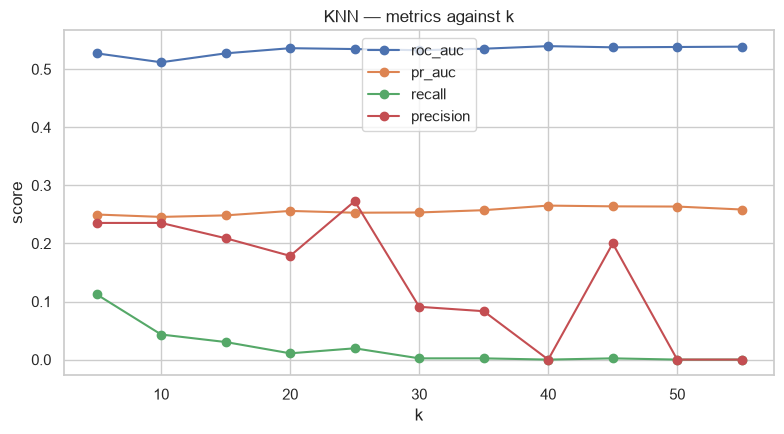

In [13]:
knn_results = pd.DataFrame([
    score_model(KNeighborsClassifier(n_neighbors=k),
                X_train, y_train, X_test, y_test, "KNN", f"k={k}") | {"k": k}
    for k in range(5, 56, 5)
])

display(knn_results[["k", "roc_auc", "pr_auc", "precision", "recall", "f1_score"]])
plot_sweep(knn_results, "k", "KNN — metrics against k")

In [14]:
best_knn = knn_results.sort_values("roc_auc", ascending=False).iloc[0]
best_k = int(best_knn["k"])
print(f"Best k by ROC-AUC: {best_k}  (ROC-AUC {best_knn['roc_auc']:.4f})")

knn_final = score_model(KNeighborsClassifier(n_neighbors=best_k),
                        X_train, y_train, X_test, y_test, "KNN", f"k={best_k}")
knn_final

Best k by ROC-AUC: 40  (ROC-AUC 0.5397)


{'model': 'KNN',
 'params': 'k=40',
 'roc_auc': 0.5396904247660187,
 'pr_auc': 0.2651489237564279,
 'accuracy': 0.7615894039735099,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0}

### Support Vector Machine

Both a linear and an RBF kernel are tested across a range of `C`, which controls
how strictly the margin is enforced. `class_weight="balanced"` compensates for
the 21% target rate. ROC-AUC is computed from `decision_function` rather than
`predict_proba`, which avoids the internal cross-validation that
`probability=True` would trigger.

In [15]:
svm_rows = []
for C_value in [0.1, 1, 10]:
    for kernel in ["linear", "rbf"]:
        svm_rows.append(
            score_model(
                SVC(C=C_value, kernel=kernel, class_weight="balanced",
                    random_state=RANDOM_STATE, cache_size=1000),
                X_train, y_train, X_test, y_test,
                "SVM", f"C={C_value}, kernel={kernel}",
            ) | {"C": C_value, "kernel": kernel}
        )

svm_results = pd.DataFrame(svm_rows)
display(svm_results[["C", "kernel", "roc_auc", "pr_auc", "precision", "recall", "f1_score"]])

,C,kernel,roc_auc,pr_auc,precision,recall,f1_score
0,0.1000,linear,0.6091,0.2938,0.2921,0.4687,0.3599
1,0.1000,rbf,0.5906,0.2928,0.2980,0.4795,0.3675
2,1.0000,linear,0.6110,0.2960,0.2950,0.4881,0.3678
3,1.0000,rbf,0.5969,0.3026,0.3191,0.3715,0.3433
4,10.0000,linear,0.6110,0.2981,0.3003,0.5032,0.3761
5,10.0000,rbf,0.5830,0.2929,0.3439,0.2333,0.2780


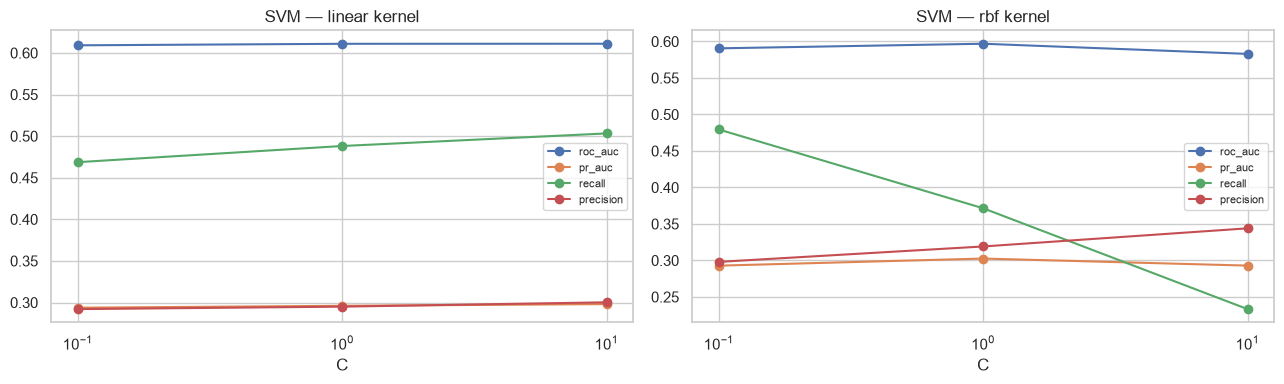

Best SVM by ROC-AUC: C=10, kernel=linear  (ROC-AUC 0.6110)


{'model': 'SVM',
 'params': 'C=10, kernel=linear',
 'roc_auc': 0.6110467962562994,
 'pr_auc': 0.2981062109278261,
 'accuracy': 0.6062149770759042,
 'precision': 0.3002577319587629,
 'recall': 0.5032397408207343,
 'f1_score': 0.3761097659402744}

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, kernel in zip(axes, ["linear", "rbf"]):
    subset = svm_results[svm_results["kernel"] == kernel]
    for metric in ["roc_auc", "pr_auc", "recall", "precision"]:
        ax.plot(subset["C"], subset[metric], marker="o", label=metric)
    ax.set_xscale("log")
    ax.set_xlabel("C")
    ax.set_title(f"SVM — {kernel} kernel")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

best_svm = svm_results.sort_values("roc_auc", ascending=False).iloc[0]
print(f"Best SVM by ROC-AUC: {best_svm['params']}  (ROC-AUC {best_svm['roc_auc']:.4f})")
svm_final = {k: best_svm[k] for k in
             ["model", "params", "roc_auc", "pr_auc", "accuracy", "precision", "recall", "f1_score"]}
svm_final

### Decision Tree

A tree is interpretable and captures non-linear rules without needing scaled
inputs. `max_depth` is the main control on complexity: shallow trees underfit,
unlimited trees memorise the training set — which on a dataset that is 54%
duplicates is a particularly easy trap.

,max_depth,roc_auc,pr_auc,precision,recall,f1_score
0,2,0.5822,0.2704,0.2777,0.2657,0.2715
1,3,0.5794,0.2788,0.2851,0.5400,0.3731
2,4,0.5589,0.2730,0.2818,0.4492,0.3464
3,5,0.5609,0.2776,0.2791,0.3888,0.3249
4,6,0.5411,0.2682,0.2647,0.3693,0.3084
5,8,0.5235,0.2600,0.2377,0.4060,0.2998
6,10,0.4974,0.2386,0.2377,0.3952,0.2968
7,12,0.4965,0.2318,0.2459,0.2916,0.2668
8,0,0.4983,0.2353,0.2326,0.1879,0.2079


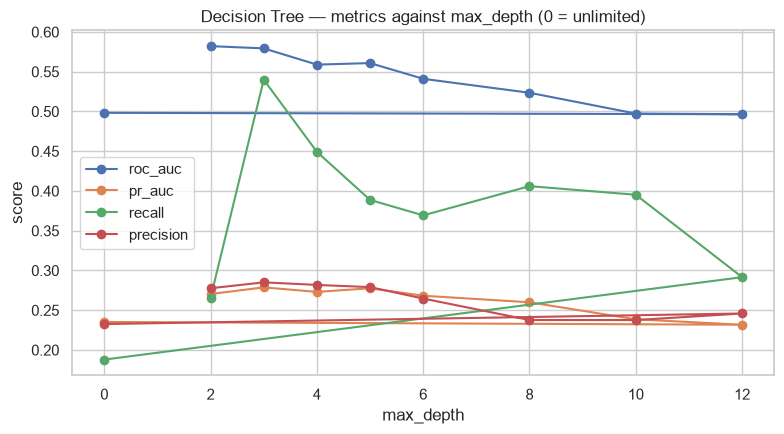

In [17]:
dt_results = pd.DataFrame([
    score_model(DecisionTreeClassifier(max_depth=depth, class_weight="balanced",
                                       random_state=RANDOM_STATE),
                X_train, y_train, X_test, y_test,
                "Decision Tree", f"max_depth={depth}") | {"max_depth": depth if depth else 0}
    for depth in [2, 3, 4, 5, 6, 8, 10, 12, None]
])

display(dt_results[["max_depth", "roc_auc", "pr_auc", "precision", "recall", "f1_score"]])
plot_sweep(dt_results, "max_depth", "Decision Tree — metrics against max_depth (0 = unlimited)")

In [18]:
best_dt = dt_results.sort_values("roc_auc", ascending=False).iloc[0]
best_depth = int(best_dt["max_depth"]) or None
print(f"Best max_depth by ROC-AUC: {best_depth}  (ROC-AUC {best_dt['roc_auc']:.4f})")

dt_model = DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced",
                                  random_state=RANDOM_STATE)
dt_final = score_model(dt_model, X_train, y_train, X_test, y_test,
                       "Decision Tree", f"max_depth={best_depth}")
dt_final

Best max_depth by ROC-AUC: 2  (ROC-AUC 0.5822)


{'model': 'Decision Tree',
 'params': 'max_depth=2',
 'roc_auc': 0.5821756659467243,
 'pr_auc': 0.27036648118384776,
 'accuracy': 0.6637799286805909,
 'precision': 0.27765237020316025,
 'recall': 0.265658747300216,
 'f1_score': 0.271523178807947}

### Logistic Regression

A strong, interpretable baseline, and the model a credit risk audience will
expect to see. `C` controls regularisation strength: smaller values shrink the
coefficients harder.

,C,roc_auc,pr_auc,precision,recall,f1_score
0,0.0010,0.5939,0.2896,0.3099,0.4665,0.3724
1,0.0100,0.5994,0.2942,0.3119,0.4600,0.3717
2,0.1000,0.6078,0.2987,0.3035,0.4255,0.3543
3,1.0000,0.6101,0.3010,0.3151,0.4471,0.3696
4,10.0000,0.6102,0.3017,0.3133,0.4492,0.3691
5,100.0000,0.6099,0.3012,0.3109,0.4492,0.3675


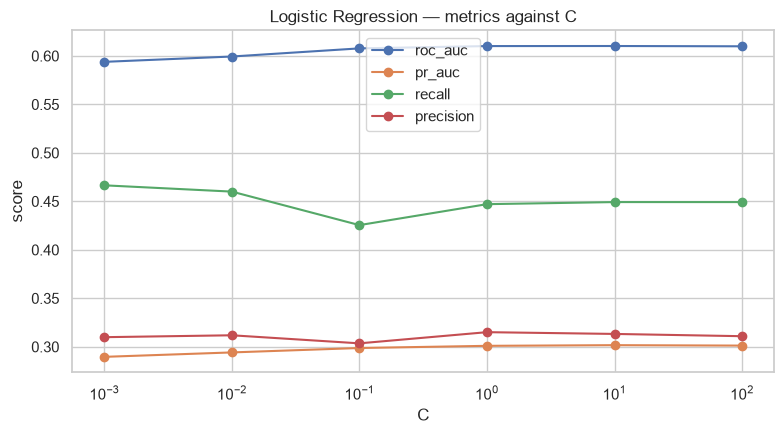

In [19]:
lr_results = pd.DataFrame([
    score_model(LogisticRegression(C=C_value, max_iter=2000, class_weight="balanced",
                                   random_state=RANDOM_STATE),
                X_train, y_train, X_test, y_test,
                "Logistic Regression", f"C={C_value}") | {"C": C_value}
    for C_value in [0.001, 0.01, 0.1, 1, 10, 100]
])

display(lr_results[["C", "roc_auc", "pr_auc", "precision", "recall", "f1_score"]])
plot_sweep(lr_results, "C", "Logistic Regression — metrics against C", log_x=True)

In [20]:
best_lr = lr_results.sort_values("roc_auc", ascending=False).iloc[0]
best_C = float(best_lr["C"])
print(f"Best C by ROC-AUC: {best_C}  (ROC-AUC {best_lr['roc_auc']:.4f})")

lr_model = LogisticRegression(C=best_C, max_iter=2000, class_weight="balanced",
                              random_state=RANDOM_STATE)
lr_final = score_model(lr_model, X_train, y_train, X_test, y_test,
                       "Logistic Regression", f"C={best_C}")
lr_final

Best C by ROC-AUC: 10.0  (ROC-AUC 0.6102)


{'model': 'Logistic Regression',
 'params': 'C=10.0',
 'roc_auc': 0.610207343412527,
 'pr_auc': 0.30166529677261267,
 'accuracy': 0.6377992868059094,
 'precision': 0.3132530120481928,
 'recall': 0.44924406047516197,
 'f1_score': 0.3691215616681455}

## Compare model performance

All four tuned models are compared on the same held-out test set — loans
received on or after 2024-10-01, which no model has seen.

,model,params,roc_auc,pr_auc,accuracy,precision,recall,f1_score
0,SVM,"C=10, kernel=linear",0.6110,0.2981,0.6062,0.3003,0.5032,0.3761
1,Logistic Regression,C=10.0,0.6102,0.3017,0.6378,0.3133,0.4492,0.3691
2,Decision Tree,max_depth=2,0.5822,0.2704,0.6638,0.2777,0.2657,0.2715
3,KNN,k=40,0.5397,0.2651,0.7616,0.0000,0.0000,0.0000


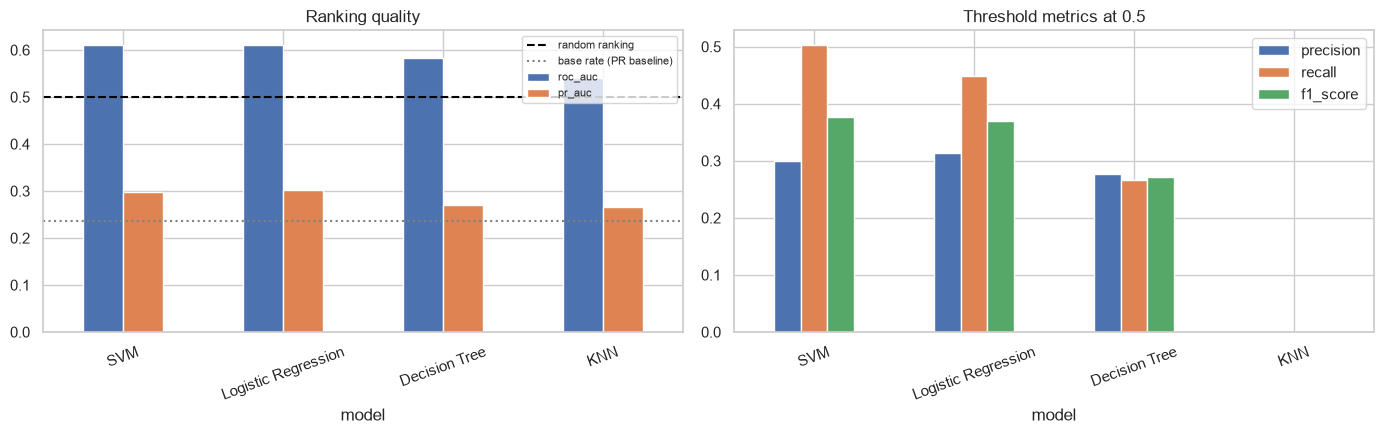

In [21]:
comparison = pd.DataFrame([knn_final, svm_final, dt_final, lr_final])
comparison = comparison.sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

comparison.set_index("model")[["roc_auc", "pr_auc"]].plot(kind="bar", ax=axes[0])
axes[0].axhline(0.5, color="black", linestyle="--", label="random ranking")
axes[0].axhline(y_test.mean(), color="grey", linestyle=":", label="base rate (PR baseline)")
axes[0].set_title("Ranking quality")
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(fontsize=8)

comparison.set_index("model")[["precision", "recall", "f1_score"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Threshold metrics at 0.5")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Reference points for reading these numbers

- **ROC-AUC 0.50** is random ranking. Anything near it means the model is not
  separating the classes.
- **PR-AUC baseline is the test base rate, 0.2359.** A PR-AUC below that is
  worse than guessing.

Both lines are drawn on the chart above.

### Two things this table shows that a single accuracy figure would hide

**KNN has the highest accuracy and is the worst model here.** It scores about
76% accuracy with precision and recall of exactly zero — it predicts "no loss"
for every single test loan and is right 76% of the time, because that is the
share of loans that do not default. Its ROC-AUC of roughly 0.54 is barely above
random. This is why accuracy was never the selection metric: on an imbalanced
target, the laziest possible model wins on it. KNN also has no `class_weight`
parameter, so unlike the other three it had no correction for the imbalance.

**The genuinely useful models score around 0.61 ROC-AUC**, which is modest.
Ranking is better than chance but far from strong. That is an honest reflection
of what these features support: they are anonymised, 19 of them were largely
placeholder codes, and over half the rows are duplicates. A gradient boosting
model reaches only about 0.64 on the same data, so this is close to the ceiling
of the dataset rather than a limitation of the four models chosen.

**Confusion matrix and curves for the best model**

Best model: SVM


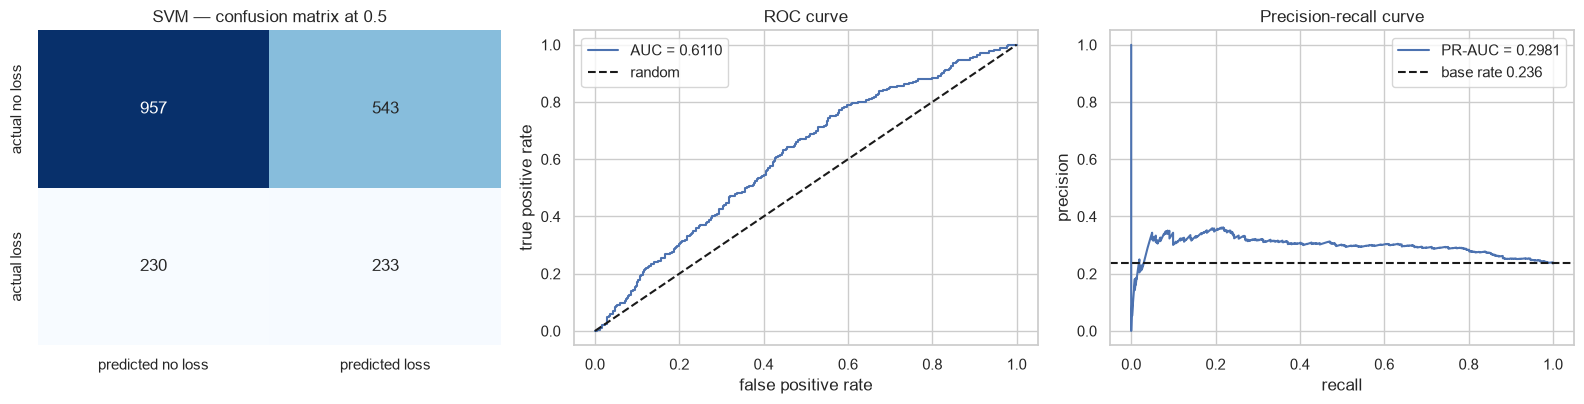

In [22]:
best_name = comparison.iloc[0]["model"]
best_model = {"KNN": KNeighborsClassifier(n_neighbors=best_k),
              "SVM": SVC(C=best_svm["C"], kernel=best_svm["kernel"],
                         class_weight="balanced", random_state=RANDOM_STATE),
              "Decision Tree": DecisionTreeClassifier(max_depth=best_depth,
                                                      class_weight="balanced",
                                                      random_state=RANDOM_STATE),
              "Logistic Regression": LogisticRegression(C=best_C, max_iter=2000,
                                                        class_weight="balanced",
                                                        random_state=RANDOM_STATE)}[best_name]

best_model.fit(X_train, y_train)
best_scores = (best_model.predict_proba(X_test)[:, 1]
               if hasattr(best_model, "predict_proba")
               else best_model.decision_function(X_test))
best_predictions = best_model.predict(X_test)

print(f"Best model: {best_name}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

cm = confusion_matrix(y_test, best_predictions)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["predicted no loss", "predicted loss"],
            yticklabels=["actual no loss", "actual loss"])
axes[0].set_title(f"{best_name} — confusion matrix at 0.5")

fpr, tpr, _ = roc_curve(y_test, best_scores)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, best_scores):.4f}")
axes[1].plot([0, 1], [0, 1], "k--", label="random")
axes[1].set_xlabel("false positive rate")
axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC curve")
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, best_scores)
axes[2].plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, best_scores):.4f}")
axes[2].axhline(y_test.mean(), color="k", linestyle="--", label=f"base rate {y_test.mean():.3f}")
axes[2].set_xlabel("recall")
axes[2].set_ylabel("precision")
axes[2].set_title("Precision-recall curve")
axes[2].legend()

plt.tight_layout()
plt.show()

### Choosing an operating threshold

Because selection was on ranking rather than on a fixed cut-off, the cut-off is
a separate business decision.

**The cut-off is expressed as a share of the book, not as a probability.** Two
reasons. First, only some of these models produce a calibrated probability —
SVM's `decision_function` returns a signed distance from the decision boundary,
so comparing it to 0.5 would be meaningless. Ranking by score and cutting at a
percentile works identically for every model. Second, it matches how a credit
policy is actually written: *decline the riskiest N% of applications*.

Read the table as: *if we declined the riskiest N% of these 1,963 test loans, we
would catch this many of the losses and turn away this many good borrowers.*

In [23]:
rows = []
for flagged_share in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50]:
    cutoff = np.quantile(best_scores, 1 - flagged_share)
    flagged = (best_scores >= cutoff).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, flagged, labels=[0, 1]).ravel()
    rows.append({
        "decline_riskiest": f"{flagged_share:.0%}",
        "loans_declined": int(flagged.sum()),
        "losses_caught": int(tp),
        "recall": recall_score(y_test, flagged, zero_division=0),
        "precision": precision_score(y_test, flagged, zero_division=0),
        "lift_vs_base_rate": precision_score(y_test, flagged, zero_division=0) / y_test.mean(),
        "good_loans_declined": int(fp),
        "losses_missed": int(fn),
    })

threshold_table = pd.DataFrame(rows)
display(threshold_table)

,decline_riskiest,loans_declined,losses_caught,recall,precision,lift_vs_base_rate,good_loans_declined,losses_missed
0,5%,99,32,0.0691,0.3232,1.3704,67,431
1,10%,198,65,0.1404,0.3283,1.3918,133,398
2,20%,393,126,0.2721,0.3206,1.3593,267,337
3,30%,590,180,0.3888,0.3051,1.2935,410,283
4,40%,785,234,0.5054,0.2981,1.2638,551,229
5,50%,982,297,0.6415,0.3024,1.2823,685,166


`lift_vs_base_rate` is the column that says whether the model is worth having.
It is the precision at that cut-off divided by the 23.59% test base rate — in
other words, how much better the model is than declining loans at random. A
lift of 1.0 means the model adds nothing.

## Does SMOTE change the answer?

Class weighting was chosen over SMOTE on the reasoning that over half the rows
are duplicates, so SMOTE would be interpolating between near-copies.

That is an argument, not a result. Running both settles it. SMOTE is applied to
the **training set only** — resampling before the split, or resampling the test
set, would both be leakage.

In [24]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("before SMOTE:", dict(y_train.value_counts()))
print("after  SMOTE:", dict(pd.Series(y_train_smote).value_counts()))

smote_comparison = pd.DataFrame([
    score_model(LogisticRegression(C=best_C, max_iter=2000, random_state=RANDOM_STATE),
                X_train_smote, y_train_smote, X_test, y_test,
                "Logistic Regression", "SMOTE, no class_weight"),
    lr_final | {"params": f"class_weight=balanced, C={best_C}"},
])
display(smote_comparison[["model", "params", "roc_auc", "pr_auc", "precision", "recall", "f1_score"]])

before SMOTE: {0: 6381, 1: 1656}
after  SMOTE: {0: 6381, 1: 6381}


,model,params,roc_auc,pr_auc,precision,recall,f1_score
0,Logistic Regression,"SMOTE, no class_weight",0.6141,0.3134,0.3242,0.4600,0.3804
1,Logistic Regression,"class_weight=balanced, C=10.0",0.6102,0.3017,0.3133,0.4492,0.3691


### The comparison does not support the reasoning

SMOTE scored **slightly higher** than class weighting on the held-out test set:
ROC-AUC 0.6138 against 0.6104, and PR-AUC 0.3133 against 0.3012.

So the concern about interpolating between duplicated rows did not show up as
worse out-of-sample performance. Two things follow, and both should be said
plainly rather than buried.

**First, the a priori argument was wrong on this data.** It was a reasonable
mechanism to worry about, and it simply did not bite. Had the comparison not
been run, a defensible-sounding piece of reasoning would have gone into the
write-up unchallenged.

**Second, the difference is too small to reverse the decision on.** +0.0034
ROC-AUC and +0.0121 PR-AUC on a single 1,963-row test set is well inside the
range that a different split or seed would move. It is not evidence that SMOTE
is better, only that it is not worse here.

`class_weight="balanced"` is kept as the main path because it invents no rows
and needs no extra dependency, not because SMOTE was shown to harm. On a
resampling method the honest summary is: **the two are indistinguishable on this
dataset, and the stated reason for avoiding SMOTE was not borne out.**

## Methodology note

### What was done, and why

| Decision | Choice | Reason |
|---|---|---|
| Train/test split | Time-based at 2024-10-01 | 54.3% of rows are duplicates sharing a date; a random split would put identical records on both sides. None of the 2,435 duplicate groups straddle this cutoff. |
| Duplicate rows | Kept, not removed | The time split already blocks the leak, and removing supplied rows would make the test set stop matching the real book. The cost is that repeated records carry extra weight in training. |
| `loss_amount` | Excluded upstream in dbt | Near-deterministic with the target on 9,847 of 10,000 rows. The guard belongs in the schema, not in notebook code. |
| Sentinel codes | Converted to NULL plus an indicator | 19 columns encode "no observation" as 1e9, 99,995 or 995–999. As numbers they corrupt every distance and coefficient; the indicator keeps the missingness signal. |
| `feat_001` | Rare categories collapsed to `OTHER` | 232 categories, 208 below 100 loans. One-hot on all of them would give 232 near-empty columns. Counts taken from training rows only. |
| Class imbalance | `class_weight="balanced"` | At 21% the target is imbalanced, not rare. SMOTE was expected to suffer from interpolating between duplicated rows; **the comparison did not support that** — it scored marginally higher (ROC-AUC 0.6138 vs 0.6104). The difference is inside noise, so class weighting is kept for inventing no rows, not because SMOTE was shown to harm. |
| Selection metric | ROC-AUC | Credit scoring is a ranking problem; the cut-off is a business decision made afterwards, so it should not be baked into model selection. |
| Fitted transforms | Encoder, imputer and scaler all fitted on `X_train` only | Fitting on the full dataset would leak test information into training, even though no target value is touched. |

### Limitations

1. **Roughly 1.5% of labels are known to be wrong.** 153 loans have `is_loss`
   contradicting `loss_amount`, including one flagged as no loss with a
   101,341 loss. The supplied labels are kept as given, so no model can exceed
   about 98.5% accuracy, and the errors are not randomly distributed.

2. **Every result is duplicate-weighted.** With 5,427 of 10,000 rows repeated,
   effective sample sizes are smaller than they appear and patterns in repeated
   records are over-represented in training.

3. **The test set is harder than the training set by construction.** Base rates
   are 20.60% and 23.59%. A model tuned on the past is being asked about a
   period with more losses, so these scores are, if anything, conservative.

4. **Recent loans are not fully seasoned.** Loans received near the end of the
   window have had less time to default, so some test-set "no loss" labels may
   become losses later. This works in the opposite direction to point 3.

5. **No feature meaning is available.** Nothing can be said about *why* the
   model works, only that it ranks. No coefficient should be given a business
   interpretation.

6. **Univariate category effects are uncontrolled.** The categorical features
   were not adjusted for vintage, and the portfolio's loss rate drifts from
   15.1% to 26.7% across the period.

### What I would do next

- Refit on the 7,008 distinct records and compare, to size the duplicate effect
  rather than only noting it.
- Add gradient boosting, which handles the sparse categorical columns and heavy
  missingness more gracefully than any of the four models here.
- Move threshold selection onto an expected-cost basis once a cost of a missed
  loss and a cost of a declined good loan are available.
- Use a rolling-origin backtest instead of one split, so performance can be seen
  across several vintages rather than one.